In [6]:
install.packages("readr")

library(readr)

df <- read.csv("ufo.csv")

View(df)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



City,Colors.Reported,Shape.Reported,State,Time
<chr>,<chr>,<chr>,<chr>,<chr>
Ithaca,,TRIANGLE,NY,6/1/1930 22:00
Willingboro,,OTHER,NJ,6/30/1930 20:00
Holyoke,,OVAL,CO,2/15/1931 14:00
Abilene,,DISK,KS,6/1/1931 13:00
New York Worlds Fair,,LIGHT,NY,4/18/1933 19:00
Valley City,,DISK,ND,9/15/1934 15:30
Crater Lake,,CIRCLE,CA,6/15/1935 0:00
Alma,,DISK,MI,7/15/1936 0:00
Eklutna,,CIGAR,AK,10/15/1936 17:00


In [7]:
# 1. Load
library(dplyr)
library(tidyr)
library(lubridate)

# 2. Load the dataset
ufo_df <- read_csv("ufo.csv")

# 3. Standardize
colnames(ufo_df) <- gsub(" ", "_", colnames(ufo_df))

# 4. Handle Missing Values (NAs)

ufo_cleaned <- ufo_df %>%
  drop_na(City) %>%
  replace_na(list(
    Colors_Reported = "Unknown",
    Shape_Reported = "Unknown"
  ))

# 5. Correct Data Types (Convert Time to Datetime)

ufo_cleaned <- ufo_cleaned %>%
  mutate(Time = mdy_hm(Time))

# 6. Final Clean: Remove any exact duplicate rows
ufo_cleaned <- ufo_cleaned %>%
  distinct()

# --- Verification ---
print("Dimensions after cleaning:")
print(dim(ufo_cleaned))

print("Missing values per column:")
print(colSums(is.na(ufo_cleaned)))

# View the first few rows of the cleaned data
View(ufo_cleaned)

Rows: 18241 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): City, Colors Reported, Shape Reported, State, Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Dimensions after cleaning:"
[1] 18107     5
[1] "Missing values per column:"
           City Colors_Reported  Shape_Reported           State            Time 
              0               0               0               0               0 


City,Colors_Reported,Shape_Reported,State,Time
<chr>,<chr>,<chr>,<chr>,<dttm>
Ithaca,Unknown,TRIANGLE,NY,1930-06-01 22:00:00
Willingboro,Unknown,OTHER,NJ,1930-06-30 20:00:00
Holyoke,Unknown,OVAL,CO,1931-02-15 14:00:00
Abilene,Unknown,DISK,KS,1931-06-01 13:00:00
New York Worlds Fair,Unknown,LIGHT,NY,1933-04-18 19:00:00
Valley City,Unknown,DISK,ND,1934-09-15 15:30:00
Crater Lake,Unknown,CIRCLE,CA,1935-06-15 00:00:00
Alma,Unknown,DISK,MI,1936-07-15 00:00:00
Eklutna,Unknown,CIGAR,AK,1936-10-15 17:00:00


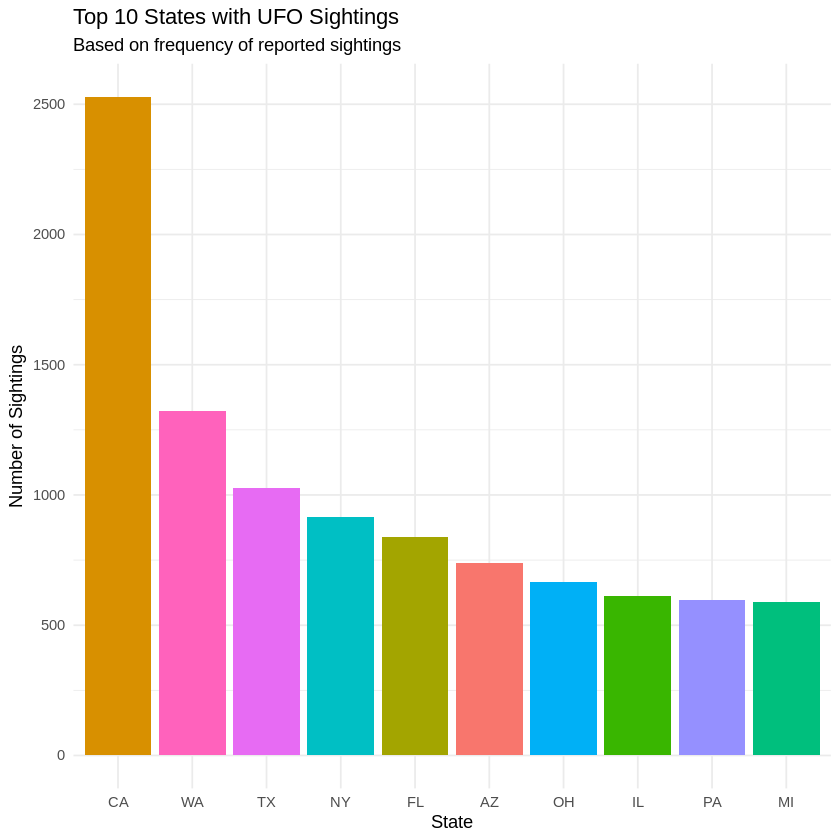

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


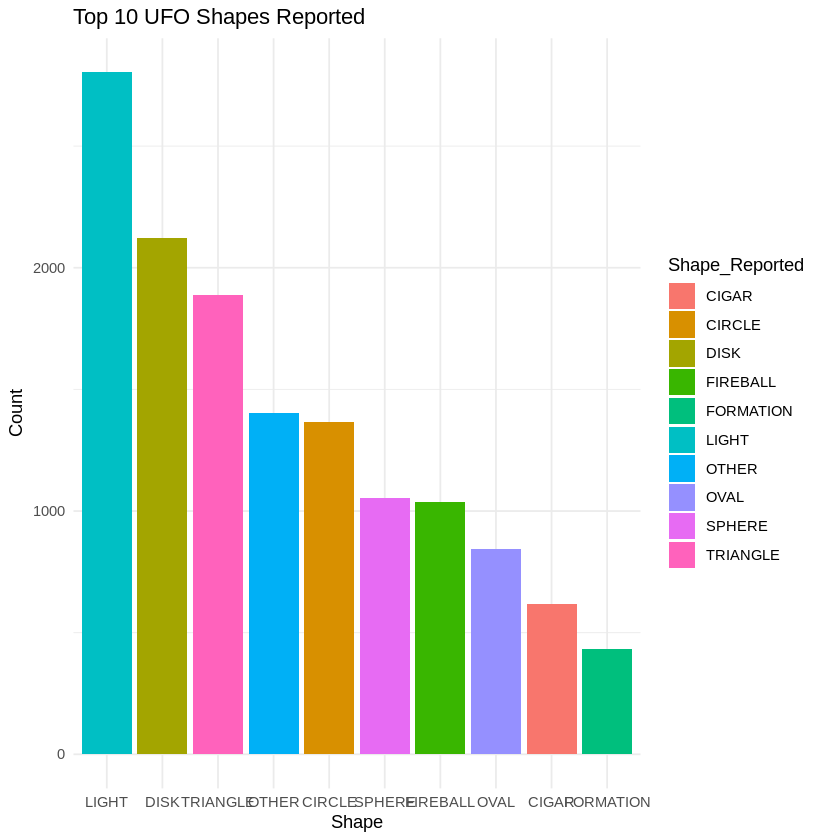

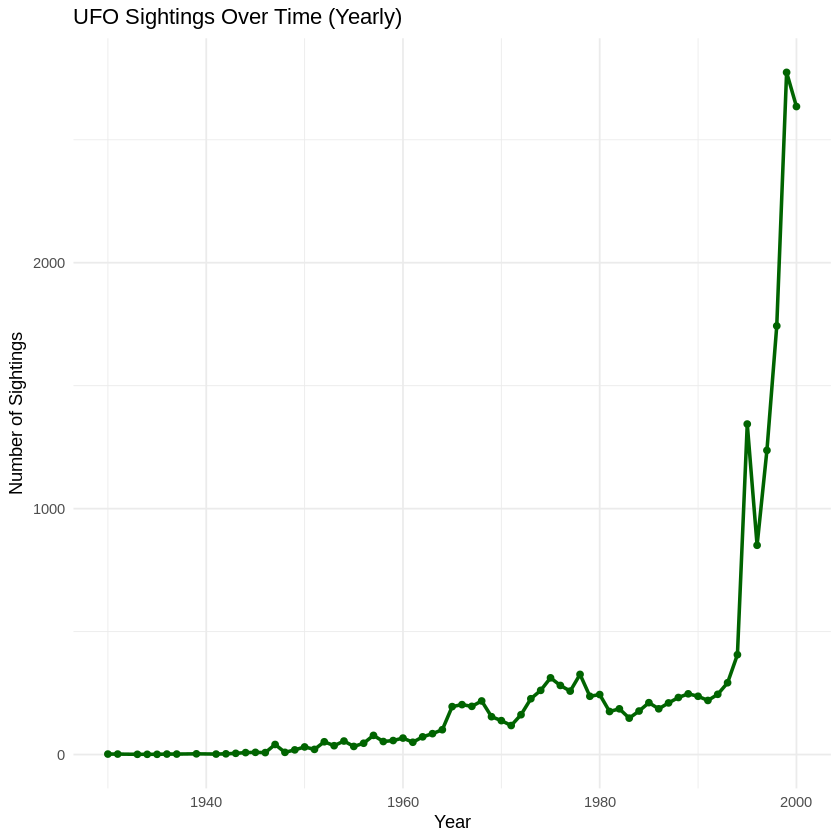

In [8]:
library(readr)
library(dplyr)
library(ggplot2)
library(lubridate)

# ==========================================
# 2. UFO Visualizations
# ==========================================

top_State <- ufo_df %>%
  filter(!is.na(State)) %>%
  count(State, sort = TRUE) %>%
  head(10)

# 2. Create the Bar Chart
ggplot(top_State, aes(x = reorder(State, -n), y = n, fill = State)) +
  geom_bar(stat = "identity") +
  # Adding labels for clarity
  labs(
    title = "Top 10 States with UFO Sightings",
    subtitle = "Based on frequency of reported sightings",
    x = "State",
    y = "Number of Sightings"
  ) +

  theme_minimal() +
  guides(fill = "none")

# Prepare UFO Top 10 Shapes
top_shapes <- ufo_df %>%
  filter(!is.na(Shape_Reported)) %>%
  count(Shape_Reported, sort = TRUE) %>%
  head(10)

# Chart: Top 10 Shapes Reported
ggplot(top_shapes, aes(x = reorder(Shape_Reported, -n), y = n, fill = Shape_Reported)) +
  geom_bar(stat = "identity") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Top 10 UFO Shapes Reported", x = "Shape", y = "Count") +
  theme_minimal()


# Prepare UFO Yearly Trend
ufo_yearly <- ufo_df %>%
  mutate(Year = year(mdy_hm(Time))) %>%
  filter(!is.na(Year)) %>%
  count(Year)

# Chart: Sightings Over Time
ggplot(ufo_yearly, aes(x = Year, y = n)) +
  geom_line(color = "darkgreen", size = 1) +
  geom_point(color = "darkgreen") +
  labs(title = "UFO Sightings Over Time (Yearly)", x = "Year", y = "Number of Sightings") +
  theme_minimal()

In [9]:
summary(ufo_cleaned)

     City           Colors_Reported    Shape_Reported        State          
 Length:18107       Length:18107       Length:18107       Length:18107      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
      Time                    
 Min.   :1930-06-01 22:00:00  
 1st Qu.:1981-06-30 13:45:00  
 Median :1996-02-29 01:15:00  
 Mean   :1989-12-24 06:36:27  
 3rd Qu.:1999-06-12 22:15:00  
 Max.   :2000-12-31 23:59:00  

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.6.0
✔ purrr   1.2.1     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 18241 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): City, Colors Reported, Shape Reported, State, Time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


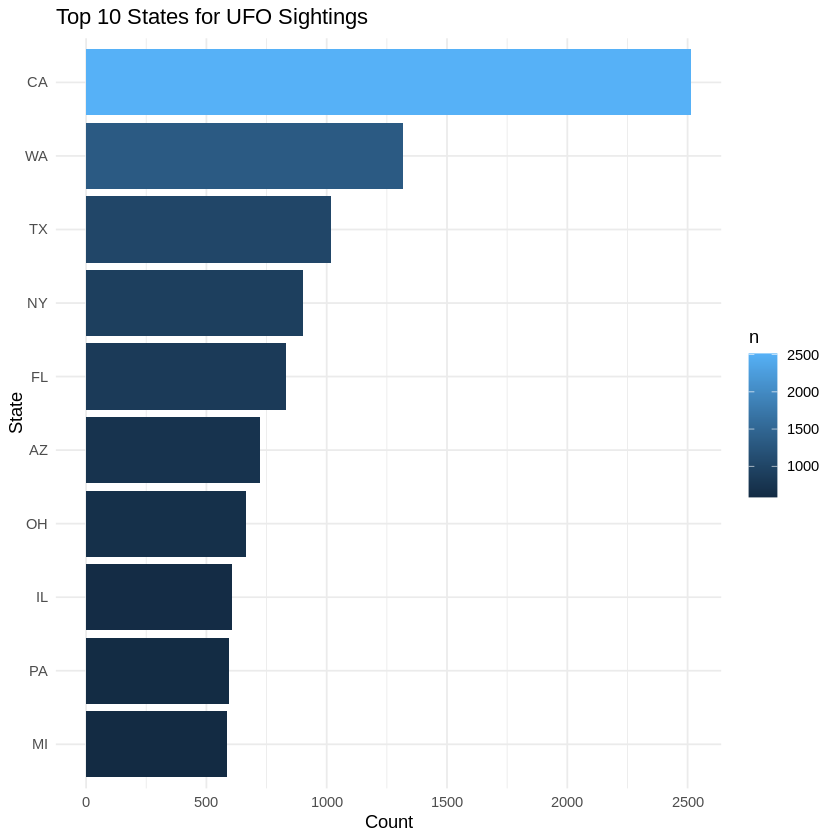

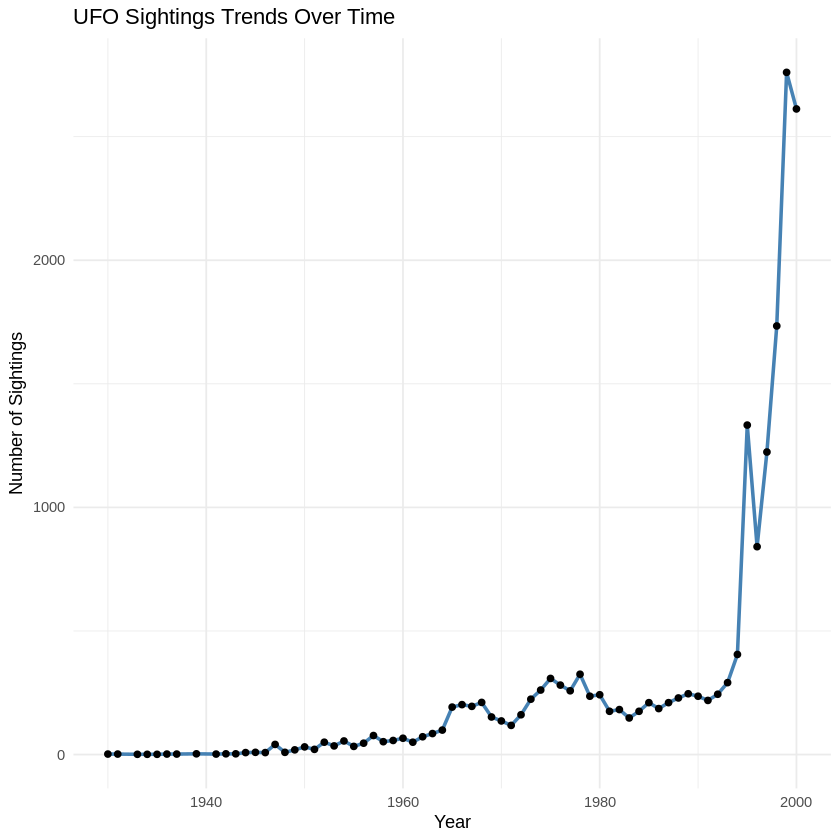

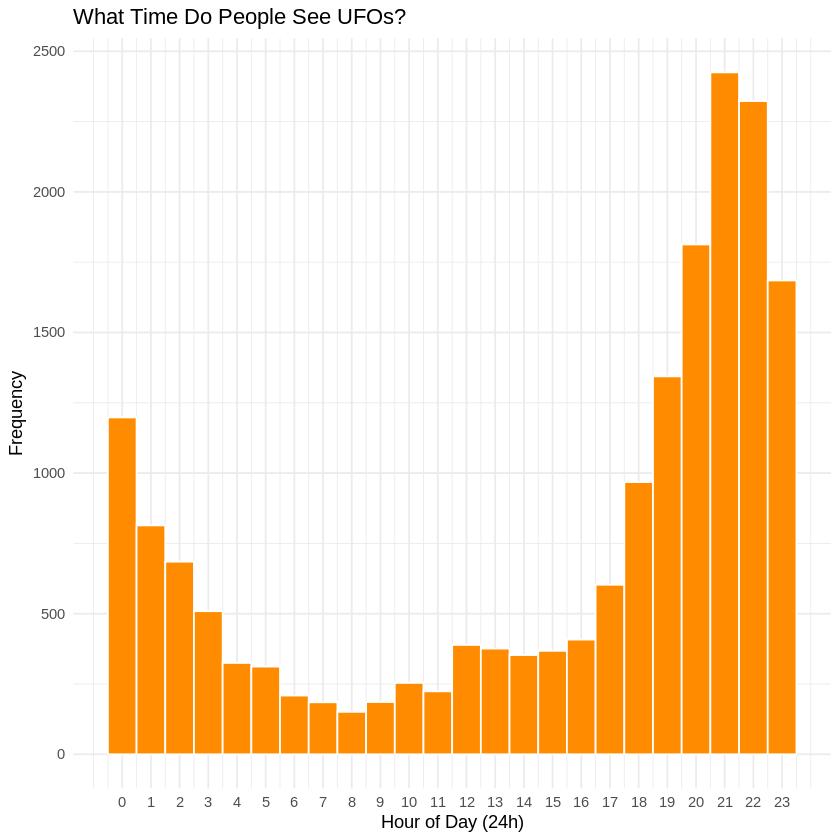

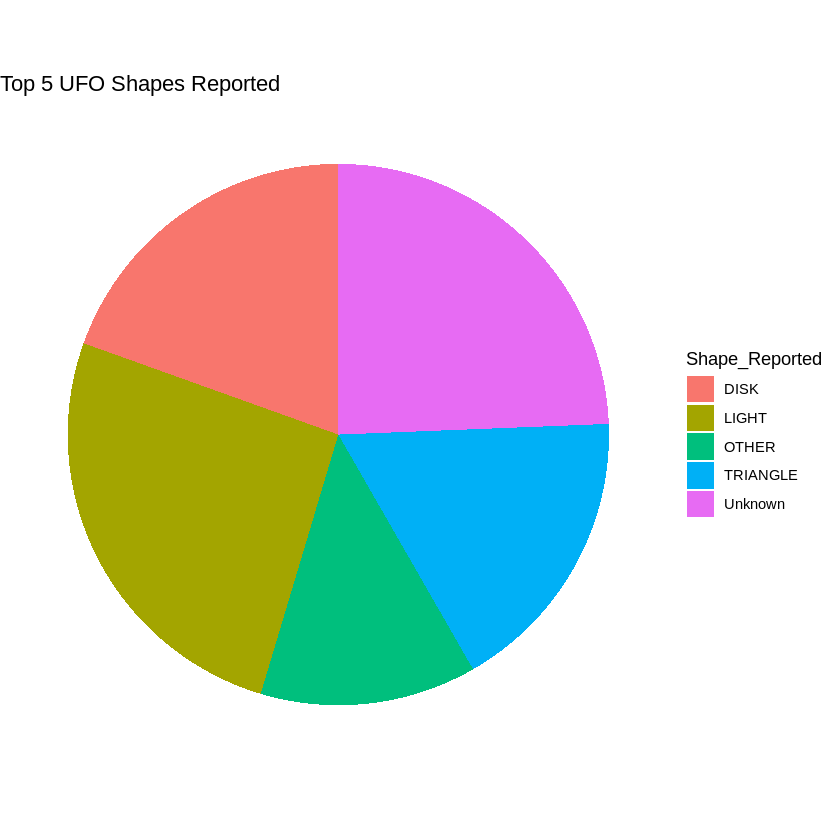

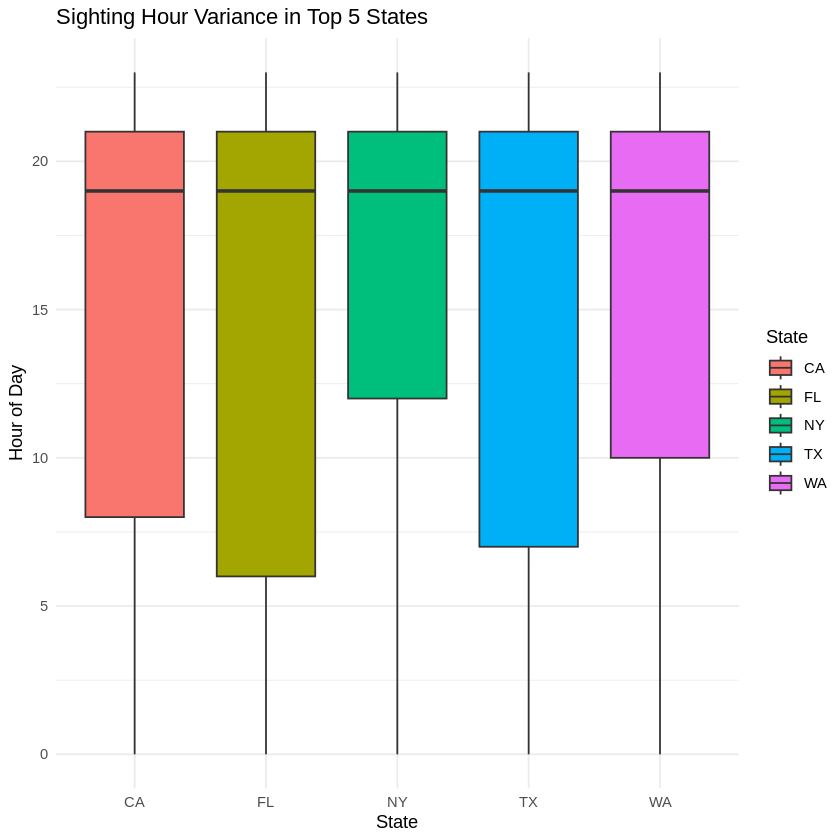

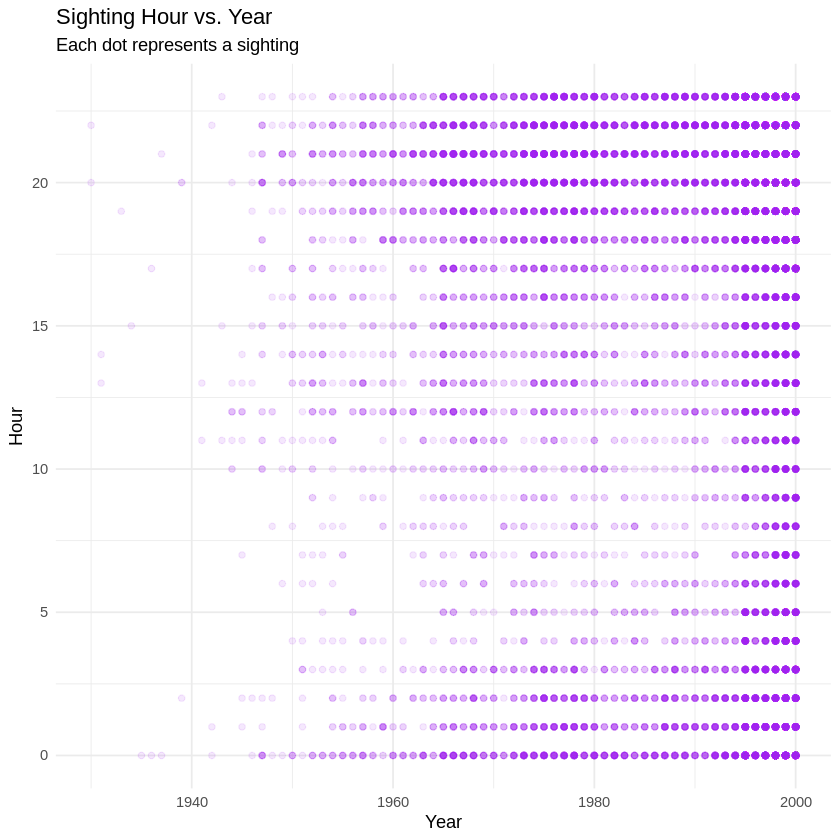

In [13]:
# 1. Install and Load Necessary Packages
if (!require("tidyverse")) install.packages("tidyverse")
library(readr)
library(dplyr)
library(tidyr)
library(lubridate)
library(ggplot2)

# 2. Load the dataset
ufo_df <- read_csv("ufo.csv")

# 3. Standardize Column Names
colnames(ufo_df) <- gsub(" ", "_", colnames(ufo_df))

# 4. Handle Missing Values (NAs)
ufo_cleaned <- ufo_df %>%
  drop_na(City) %>%
  replace_na(list(
    Colors_Reported = "Unknown",
    Shape_Reported = "Unknown"
  ))

# 5. Correct Data Types (Convert Time to Datetime)
ufo_cleaned <- ufo_cleaned %>%
  mutate(
    Time = mdy_hm(Time),
    Year = year(Time),
    Hour = hour(Time),
    Month = month(Time, label = TRUE)
  )

# 6. Final Clean: Remove exact duplicates
ufo_cleaned <- ufo_cleaned %>% distinct()

# --- VISUALIZATIONS ---

# 1. Bar Chart: Top 10 States with Most Sightings
top_states <- ufo_cleaned %>%
  count(State) %>%
  slice_max(n, n = 10)

ggplot(top_states, aes(x = reorder(State, n), y = n, fill = n)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Top 10 States for UFO Sightings", x = "State", y = "Count") +
  theme_minimal()

# 2. Line Graph: Sightings per Year
yearly_counts <- ufo_cleaned %>%
  count(Year)

ggplot(yearly_counts, aes(x = Year, y = n)) +
  geom_line(color = "steelblue", size = 1) +
  geom_point() +
  labs(title = "UFO Sightings Trends Over Time", x = "Year", y = "Number of Sightings") +
  theme_minimal()

# 3. Histogram: Distribution of Sightings by Hour
ggplot(ufo_cleaned, aes(x = Hour)) +
  geom_histogram(binwidth = 1, fill = "darkorange", color = "white") +
  scale_x_continuous(breaks = 0:23) +
  labs(title = "What Time Do People See UFOs?", x = "Hour of Day (24h)", y = "Frequency") +
  theme_minimal()

# 4. Pie Chart: Top 5 Shapes Reported
top_shapes <- ufo_cleaned %>%
  count(Shape_Reported) %>%
  slice_max(n, n = 5)

ggplot(top_shapes, aes(x = "", y = n, fill = Shape_Reported)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Top 5 UFO Shapes Reported") +
  theme_void()

# 5. Box Plot: Sighting Hour Distribution for Top 5 States
top_5_states_list <- ufo_cleaned %>% count(State) %>% slice_max(n, n = 5) %>% pull(State)
box_data <- ufo_cleaned %>% filter(State %in% top_5_states_list)

ggplot(box_data, aes(x = State, y = Hour, fill = State)) +
  geom_boxplot() +
  labs(title = "Sighting Hour Variance in Top 5 States", y = "Hour of Day") +
  theme_minimal()

# 6. Scatterplot: Year vs Hour of Sighting
ggplot(ufo_cleaned, aes(x = Year, y = Hour)) +
  geom_point(alpha = 0.1, color = "purple") +
  labs(title = "Sighting Hour vs. Year", subtitle = "Each dot represents a sighting") +
  theme_minimal()

In [16]:
install.packages("modeest")
# 1. Load the dataset
library(tidyverse)
library(modeest) # For mode calculation

titanic_df <- read_csv("titanic.csv")

# 2. Standardize column names
colnames(titanic_df) <- tolower(colnames(titanic_df))

# 3. Handle Missing Values (Imputation only)
titanic_cleaned <- titanic_df %>%
  mutate(
    # Fill missing age with the median
    age = ifelse(is.na(age), median(age, na.rm = TRUE), age),

    # Fill missing embarked with the mode ('S')
    embarked = replace_na(embarked, "S"),

    # Fill missing cabin with "Unknown" (preserving the column)
    cabin = replace_na(cabin, "Unknown")
  )

# 4. Verification
print("Dimensions after cleaning (should be 891 x 12):")
print(dim(titanic_cleaned))

print("Missing values per column (should be 0):")
print(colSums(is.na(titanic_cleaned)))

# View the cleaned data
View(titanic_cleaned)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Rows: 891 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Name, Sex, Ticket, Cabin, Embarked
dbl (7): PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Dimensions after cleaning (should be 891 x 12):"
[1] 891  12
[1] "Missing values per column (should be 0):"
passengerid    survived      pclass        name         sex         age 
          0           0           0           0           0           0 
      sibsp       parch      ticket        fare       cabin    embarked 
          0           0           0           0           0           0 


passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,Unknown,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,Unknown,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,Unknown,S
6,0,3,"Moran, Mr. James",male,28,0,0,330877,8.4583,Unknown,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,Unknown,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,Unknown,S


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



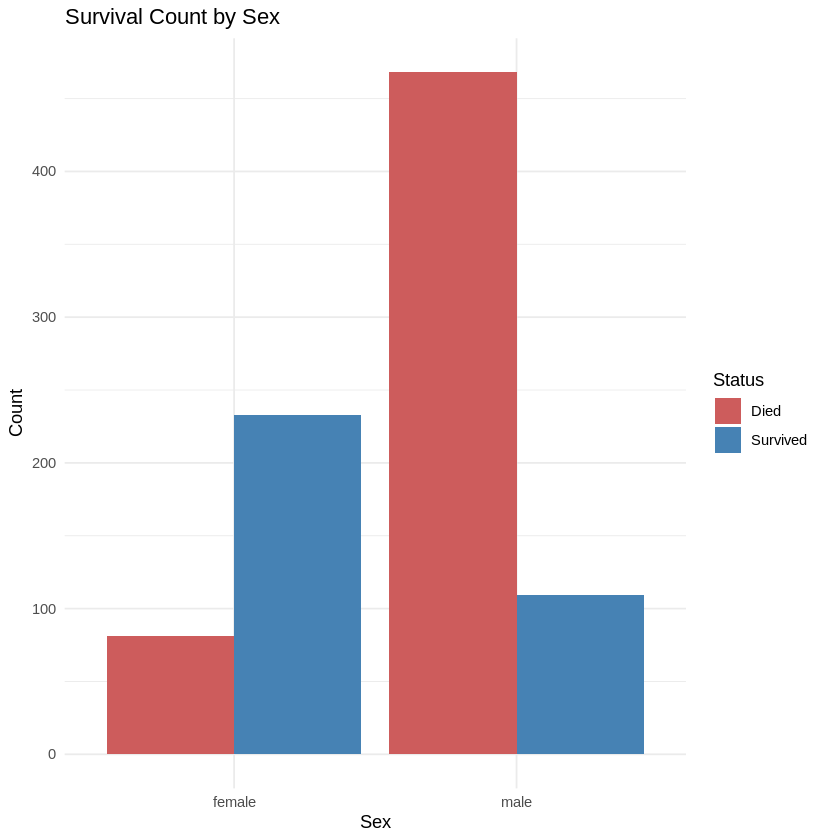

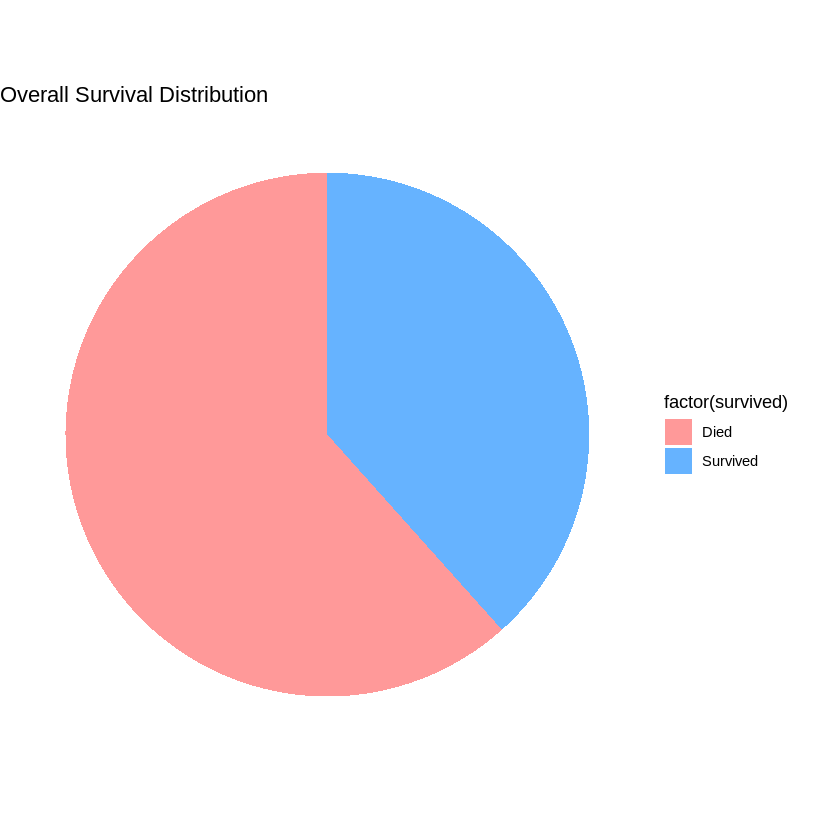

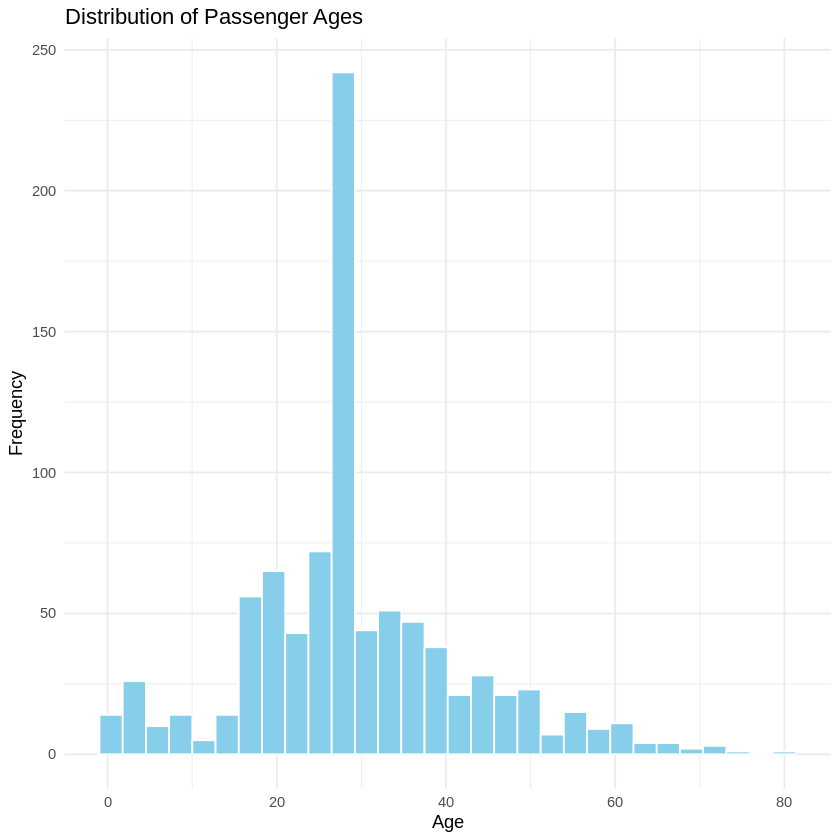

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


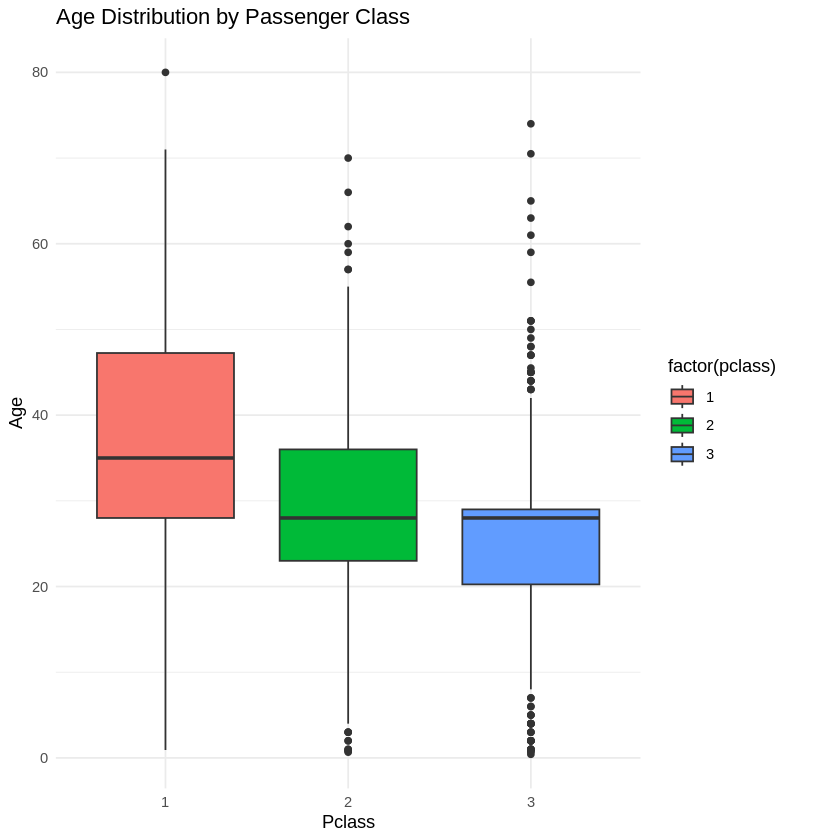

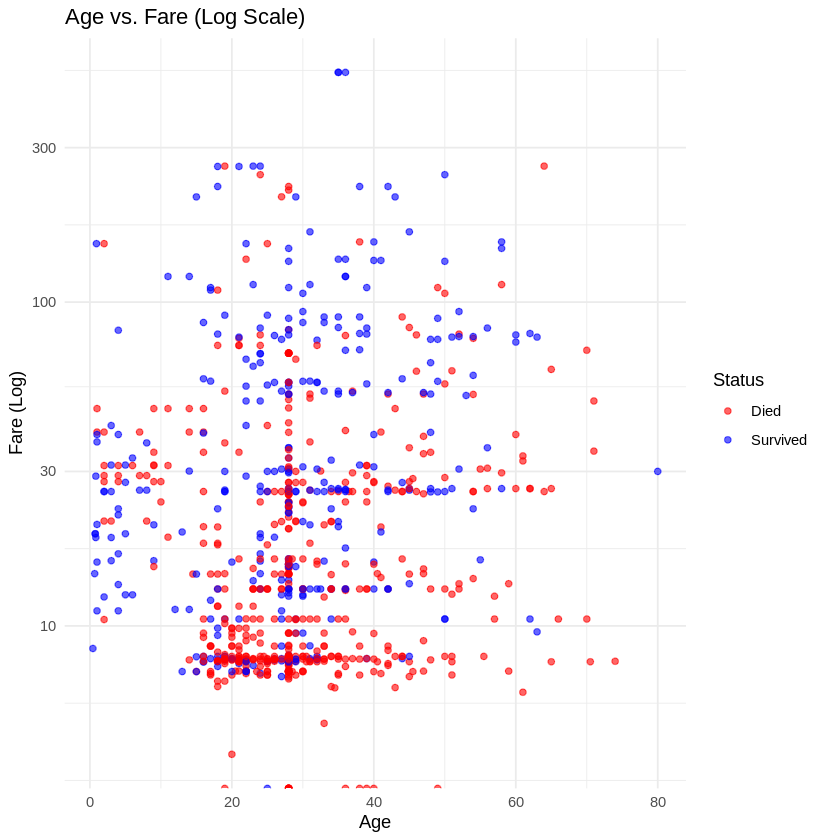

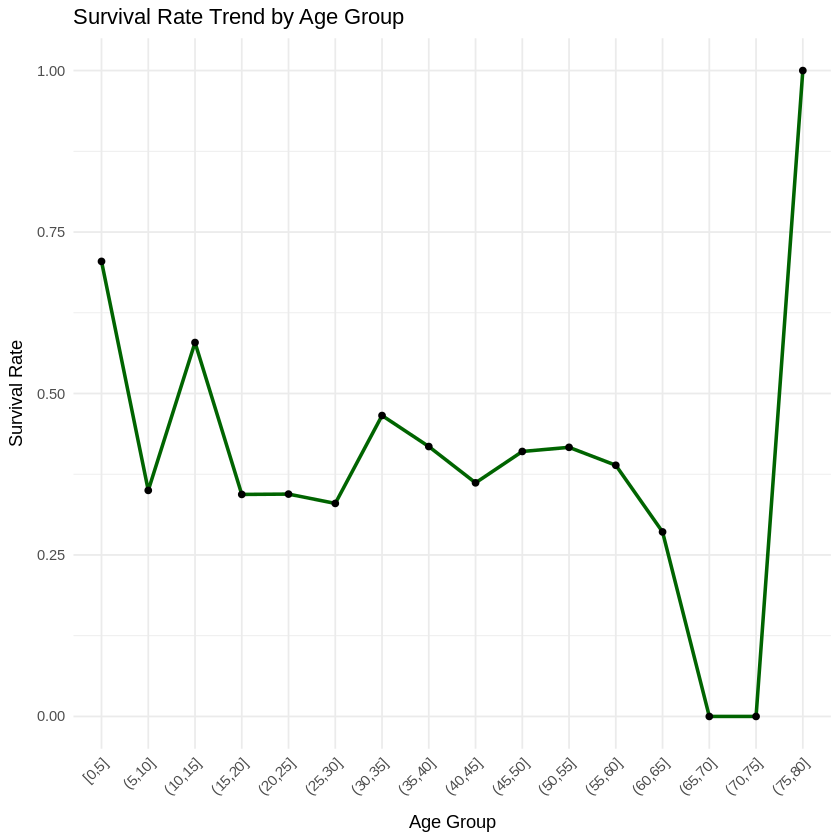

In [22]:

install.packages("tidyverse")

install.packages("scales")
# Load Libraries
library(tidyverse)
library(scales) # for log scales

# Load the filled dataset
df <- titanic_cleaned

# 1. Bar Chart: Survival by Sex
ggplot(df, aes(x = sex, fill = factor(survived))) +
  geom_bar(position = "dodge") +
  scale_fill_manual(values = c("0" = "indianred", "1" = "steelblue"),
                    labels = c("Died", "Survived")) +
  labs(title = "Survival Count by Sex", x = "Sex", y = "Count", fill = "Status") +
  theme_minimal()

# 2. Pie Chart: Overall Survival Rate
survival_summary <- df %>% count(survived)
ggplot(survival_summary, aes(x = "", y = n, fill = factor(survived))) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  scale_fill_manual(values = c("0" = "#ff9999", "1" = "#66b3ff"),
                    labels = c("Died", "Survived")) +
  labs(title = "Overall Survival Distribution") +
  theme_void()

# 3. Histogram: Age Distribution
ggplot(df, aes(x = age)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "white") +
  labs(title = "Distribution of Passenger Ages", x = "Age", y = "Frequency") +
  theme_minimal()

# 4. Box Plot: Age by Passenger Class
ggplot(df, aes(x = factor(pclass), y = age, fill = factor(pclass))) +
  geom_boxplot() +
  labs(title = "Age Distribution by Passenger Class", x = "Pclass", y = "Age") +
  theme_minimal()

# 5. Scatterplot: Age vs Fare (by Survival)
ggplot(df, aes(x = age, y = fare, color = factor(survived))) +
  geom_point(alpha = 0.6) +
  scale_y_log10() + # Log scale for better visibility of low/high fares
  scale_color_manual(values = c("0" = "red", "1" = "blue"),
                     labels = c("Died", "Survived")) +
  labs(title = "Age vs. Fare (Log Scale)", x = "Age", y = "Fare (Log)", color = "Status") +
  theme_minimal()

# 6. Line Graph: Survival Rate by Age Group (Binned)
df %>%
  mutate(age_bin = cut(age, breaks = seq(0, 80, 5), include.lowest = TRUE)) %>%
  group_by(age_bin) %>%
  summarize(survival_rate = mean(survived)) %>%
  ggplot(aes(x = age_bin, y = survival_rate, group = 1)) +
  geom_line(color = "darkgreen", size = 1) +
  geom_point() +
  labs(title = "Survival Rate Trend by Age Group", x = "Age Group", y = "Survival Rate") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))